In [2]:
# core data handling
!pip install s3fs xarray cfgrib eccodes netCDF4 dask

# GraphCast itself (installs jax, dm-haiku, chex, jraph, trimesh, etc. as deps)
!pip install --upgrade https://github.com/deepmind/graphcast/archive/master.zip

# GCS access (for pulling model weights/checkpoints, as in your original notebook)
!pip install google-cloud-storage

# if you're on GPU, install jax with CUDA support instead of the CPU default
# pip install --upgrade "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 105.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not current

In [13]:
print(list(inputs.data_vars))
print(inputs.sizes)
for var in inputs.data_vars:
    print(var, inputs[var].dims, inputs[var].shape)

['2m_temperature', 'mean_sea_level_pressure', '10m_v_component_of_wind', '10m_u_component_of_wind', 'total_precipitation_6hr', 'temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'specific_humidity', 'toa_incident_solar_radiation', 'year_progress_sin', 'year_progress_cos', 'day_progress_sin', 'day_progress_cos']
Frozen({'batch': 1, 'time': 0, 'lat': 180, 'lon': 360, 'level': 13})
2m_temperature ('batch', 'time', 'lat', 'lon') (1, 0, 180, 360)
mean_sea_level_pressure ('batch', 'time', 'lat', 'lon') (1, 0, 180, 360)
10m_v_component_of_wind ('batch', 'time', 'lat', 'lon') (1, 0, 180, 360)
10m_u_component_of_wind ('batch', 'time', 'lat', 'lon') (1, 0, 180, 360)
total_precipitation_6hr ('batch', 'time', 'lat', 'lon') (1, 0, 180, 360)
temperature ('batch', 'time', 'level', 'lat', 'lon') (1, 0, 13, 180, 360)
geopotential ('batch', 'time', 'level', 'lat', 'lon') (1, 0, 13, 180, 360)
u_component_of_wind ('batch', 'time', 'level', 'lat', 'lon') (1, 0

In [15]:
import s3fs, xarray as xr, cfgrib
from datetime import datetime, timedelta, timezone

fs = s3fs.S3FileSystem(anon=True)

# --- 1. Pull latest global GDAS cycle (current + previous state) ---
def gdas_precip_path(t):

  return f"noaa-gfs-bdp-pds/gdas.{t:%Y%m%d}/{t.hour:02d}/atmos/gdas.t{t.hour:02d}z.pgrb2.0p25.f003"

for t in (t0, t1):
  fs.get(gdas_precip_path(t), f"/tmp/{t:%Y%m%d%H}_precip.grib2")

def find_latest_available_gdas(fs, max_lookback_cycles=8):
    now = datetime.now(timezone.utc).replace(tzinfo=None)
    cycle_hour = (now.hour // 6) * 6
    candidate = now.replace(hour=cycle_hour, minute=0, second=0, microsecond=0)

    for _ in range(max_lookback_cycles):
        if fs.exists(gdas_path(candidate)):
            return candidate
        candidate -= timedelta(hours=6)

    raise RuntimeError("No available GDAS cycle found in lookback window")

t1 = find_latest_available_gdas(fs)
t0 = t1 - timedelta(hours=6)

for t in (t0, t1):
    fs.get(gdas_path(t), f"/tmp/{t:%Y%m%d%H}.grib2")

# --- 2. Convert grib2 -> GraphCast variable names/units, downsample to 1.0° ---
GRAPHCAST_LEVELS = [
    50, 100, 150, 200, 250, 300,
    400, 500, 600, 700, 850, 925, 1000
]
def load_and_rename(path, precip_path):
  plev = xr.open_dataset(path, engine="cfgrib",
                          filter_by_keys={"typeOfLevel": "isobaricInhPa"})
  plev = plev.sel(isobaricInhPa=GRAPHCAST_LEVELS)
  plev = plev.rename({"t": "temperature", "u": "u_component_of_wind",
                     "v": "v_component_of_wind", "q": "specific_humidity",
                     "gh": "geopotential", "w": "vertical_velocity",
                     "isobaricInhPa": "level"})  # <-- dimension/coordinate rename
  plev["geopotential"] *= 9.80665

  mslp = xr.open_dataset(path, engine="cfgrib",
                          filter_by_keys={"typeOfLevel": "meanSea"})
  mslp = mslp.rename({"prmsl": "mean_sea_level_pressure"})

  t2m = xr.open_dataset(path, engine="cfgrib",
                          filter_by_keys={"typeOfLevel": "heightAboveGround", "level": 2})
  t2m = t2m.rename({"t2m": "2m_temperature"})

  wind10 = xr.open_dataset(path, engine="cfgrib",
                            filter_by_keys={"typeOfLevel": "heightAboveGround", "level": 10})
  wind10 = wind10.rename({"u10": "10m_u_component_of_wind", "v10": "10m_v_component_of_wind"})

  precip = xr.open_dataset(precip_path, engine="cfgrib",
                            filter_by_keys={"typeOfLevel": "surface", "shortName": "tp"})
  precip = precip.rename({"tp": "total_precipitation_6hr"})
  precip["total_precipitation_6hr"] = precip["total_precipitation_6hr"] / 1000.0  # kg/m^2 -> m

  merged = xr.merge([plev, mslp, t2m, wind10, precip], compat="override")
  merged = merged.coarsen(latitude=4, longitude=4, boundary="trim").mean()
  return merged

ds0 = load_and_rename(f"/tmp/{t0:%Y%m%d%H}.grib2", f"/tmp/{t0:%Y%m%d%H}_precip.grib2")
ds1 = load_and_rename(f"/tmp/{t1:%Y%m%d%H}.grib2", f"/tmp/{t1:%Y%m%d%H}_precip.grib2")


batch = xr.concat([ds0, ds1], dim="time").expand_dims("batch")

# rename lat/lon to match GraphCast's expected coordinate names
batch = batch.rename({"latitude": "lat", "longitude": "lon"})

# capture the absolute timestamps before we overwrite `time` with offsets
absolute_times = batch["time"].values  # [t0, t1] as actual datetimes

# GraphCast wants `datetime` as a (batch, time) coordinate of absolute times
batch = batch.assign_coords(
    datetime=(("batch", "time"), absolute_times.reshape(1, -1))
)

# and `time` itself becomes an offset relative to the last (most recent) step
time_deltas = absolute_times - absolute_times[-1]  # e.g. [-6h, 0h]
batch = batch.assign_coords(time=time_deltas)
def load_static_fields(path):
  orog = xr.open_dataset(path, engine="cfgrib",
                          filter_by_keys={"typeOfLevel": "surface", "shortName": "orog"})
  lsm = xr.open_dataset(path, engine="cfgrib",
                          filter_by_keys={"typeOfLevel": "surface", "shortName": "lsm"})

  orog = orog.rename({"orog": "geopotential_at_surface"})
  orog["geopotential_at_surface"] *= 9.80665
  lsm = lsm.rename({"lsm": "land_sea_mask"})

  static = xr.merge([orog, lsm], compat="override")
  static = static.rename({"latitude": "lat", "longitude": "lon"})
  static = static.coarsen(lat=4, lon=4, boundary="trim").mean()
  return static.drop_vars(["time", "step", "valid_time"], errors="ignore")

static_fields = load_static_fields(f"/tmp/{t1:%Y%m%d%H}.grib2")
batch = batch.assign(
    geopotential_at_surface=(
        ("lat", "lon"),
        static_fields["geopotential_at_surface"].values
    ),
    land_sea_mask=(
        ("lat", "lon"),
        static_fields["land_sea_mask"].values
    ),
)

# --- 3. Load GraphCast_small (1.0°, 13 levels) ---
from graphcast_wrapper import GraphCastModel

model = GraphCastModel.from_gcs(
    "GraphCast_small - ERA5 1979-2015 - resolution 1.0 - "
    "pressure levels 13 - mesh 2to5 - precipitation input and output.npz"
)

# --- 4. Run inference globally ---
import numpy as np

# target_lead_times=slice("6h","24h") at 6h spacing = 4 future placeholder steps
future_offsets = np.array([6, 12, 18, 24], dtype="timedelta64[h]").astype("timedelta64[ns]")

static_vars = ["geopotential_at_surface", "land_sea_mask"]

# build placeholders WITHOUT the static fields
placeholder = batch.drop_vars(static_vars).isel(time=[-1]) * np.nan
placeholders = xr.concat(
    [placeholder.assign_coords(time=[batch["time"].values[-1] + off]) for off in future_offsets],
    dim="time",
    data_vars="minimal",
    coords="minimal",
)

full_batch = xr.concat(
    [batch.drop_vars(static_vars), placeholders],
    dim="time",
    data_vars="minimal",
    coords="minimal",
)

# reattach the real static fields once, at the end
full_batch = full_batch.assign(
    geopotential_at_surface=batch["geopotential_at_surface"],
    land_sea_mask=batch["land_sea_mask"],
)

# extend the datetime coord too — add_derived_vars/tisr forcings need it for the future steps
last_dt = batch["datetime"].values[0, -1]
future_dts = np.array([last_dt + off for off in future_offsets])
full_datetime = np.concatenate([batch["datetime"].values[0], future_dts]).reshape(1, -1)
full_batch = full_batch.assign_coords(datetime=(("batch", "time"), full_datetime))

inputs, targets_template, forcings = model.extract_inputs_targets_forcings(
    full_batch, target_lead_times=slice("6h", "24h"),
)
preds = model.predict(inputs, targets_template, forcings)

# --- 5. Crop to Bay of Bengal / Arabian Sea only for detection ---
india_region = dict(
    lat=slice(0, 30),
    lon=slice(60, 100)
)

mslp_india = preds[
    "mean_sea_level_pressure"
].sel(**india_region)

u10_india = preds[
    "10m_u_component_of_wind"
].sel(**india_region)

v10_india = preds[
    "10m_v_component_of_wind"
].sel(**india_region)

wind_india = (
    u10_india**2 + v10_india**2
) ** 0.5

ERROR:cfgrib.dataset:skipping variable: paramId==228164 shortName='tcc'
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
    ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
    ...<2 lines>...
    )
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='isobaricInhPa' value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,
        650.,  600.,  550.,  500.,  450.,  400.,  350.,  300.,  250.,
        200.,  150.,  100.,   70.,   50.,   40.,   30.,   20.,   15.,
         10.,    7.,    5.,    3.,    2.,    1.])) new_value=Variable(dimensions=('isobaricInhPa',), data=array([1000.,  975.,  950.,  925.,  900.,  850.,  800.,  750.,  700.,
        650.,  600.,  550.,  500.

Model description:
 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.
 

Model license:
 
The model weights are licensed under the Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0). You
may obtain a copy of the License at:
https://creativecommons.org/licenses/by-nc-sa/4.0/.
The weights were trained on ERA5 data, see README for attribution statement.
 



In [8]:
preds

<xarray.Dataset> Size: 86MB
Dimensions:                  (time: 4, batch: 1, lat: 180, lon: 360, level: 13)
Coordinates:
  * time                     (time) timedelta64[ns] 32B 06:00:00 ... 1 days 0...
    valid_time               (time) datetime64[ns] 32B 2026-09-01 ... 2026-09-01
  * lat                      (lat) float64 1kB 89.62 88.62 ... -88.38 -89.38
  * lon                      (lon) float64 3kB 0.375 1.375 2.375 ... 358.4 359.4
  * level                    (level) float64 104B 50.0 100.0 ... 925.0 1e+03
    step                     timedelta64[ns] 8B 00:00:00
    meanSea                  float64 8B 0.0
    heightAboveGround        float64 8B 2.0
    surface                  float64 8B 0.0
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 1MB 2.535 ... -3...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 1MB -0.06101 ......
    2m_temperature           (time, batch, lat, lon) float32 1MB 267.8 ... 221.9
    geopotential             (time, batch, level, lat, lon) float32 13MB 2.03...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 1MB 1.014e+05 .....
    specific_humidity        (time, batch, level, lat, lon) float32 13MB 1.71...
    temperature              (time, batch, level, lat, lon) float32 13MB 224....
    total_precipitation_6hr  (time, batch, lat, lon) float32 1MB 0.0003359 .....
    u_component_of_wind      (time, batch, level, lat, lon) float32 13MB -1.9...
    v_component_of_wind      (time, batch, level, lat, lon) float32 13MB -0.5...
    vertical_velocity        (time, batch, level, lat, lon) float32 13MB 0.00...

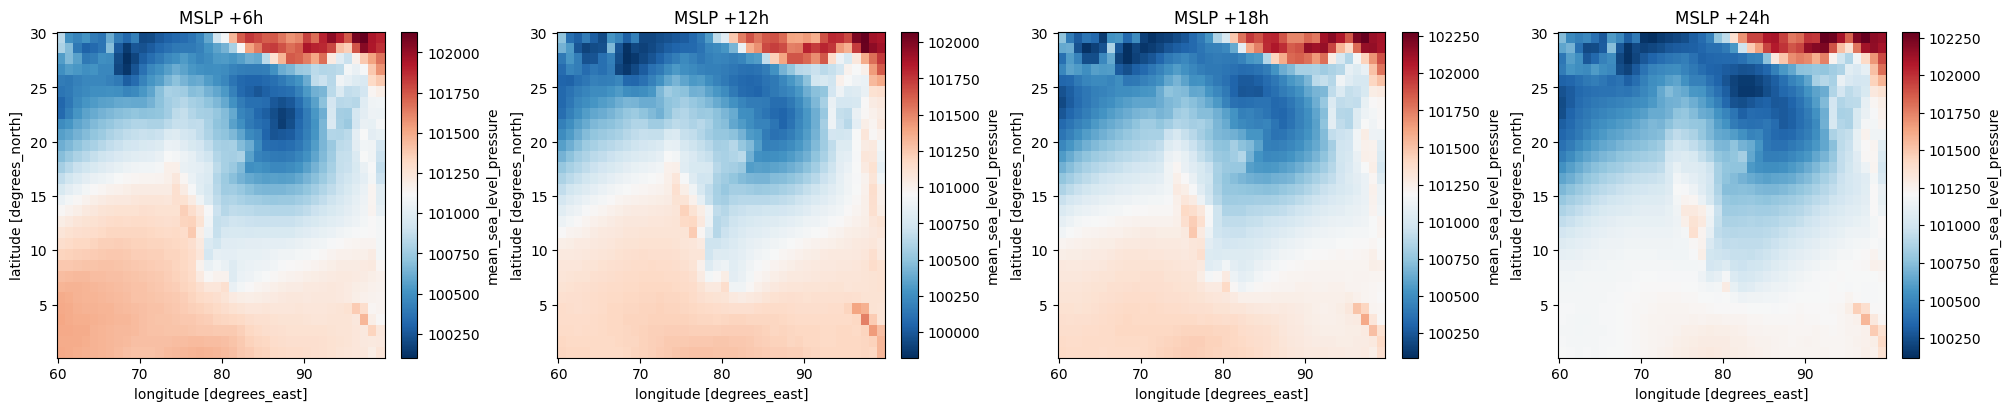

In [16]:
import matplotlib.pyplot as plt

# Correcting the slice for descending latitude coordinates
india_region_fixed = dict(
    lat=slice(30, 0),
    lon=slice(60, 100)
)

mslp_india = preds["mean_sea_level_pressure"].sel(**india_region_fixed)

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
for i, ax in enumerate(axes):
    if mslp_india.sizes['time'] > i:
        mslp_india.isel(batch=0, time=i).plot(ax=ax, cmap="RdBu_r")
        ax.set_title(f"MSLP +{6*(i+1)}h")
    else:
        ax.set_title("No data")
plt.show()